<a href="https://colab.research.google.com/github/Ozk18532/INTELIGENCIA-COMPUTACIONAL-Oscar-Mercado/blob/main/Redes_Neuronales_con_MNIST_Oscar__Mercado.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Redes Neuronales con MNIST

En este notebook se implementa una red neuronal básica usando PyTorch para clasificar imágenes del dataset MNIST.

Se entrenan tres modelos distintos variando hiperparámetros y se evalúa su desempeño.

In [1]:
# COLORES
V = '\033[92m'  # Resultados
R = '\033[91m'  # Alertas
A = '\033[94m'  # Notas
E = '\033[0m'   # Reset


## Carga de datos

Se carga el dataset MNIST y se divide en entrenamiento, validación y prueba.

In [2]:
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split

# Transformación
transform = transforms.ToTensor()

# Cargar dataset
train_dataset = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
test_dataset  = datasets.MNIST(root='./data', train=False, download=True, transform=transform)

# División
train_data, val_data = random_split(train_dataset, [50000, 10000])

print(f"{V}Train: {len(train_data)} | Val: {len(val_data)} | Test: {len(test_dataset)}{E}")

100%|██████████| 9.91M/9.91M [00:00<00:00, 20.7MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 517kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.74MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 8.81MB/s]

Train: 50000 | Val: 10000 | Test: 10000


## DataLoaders

Se crean los DataLoaders para trabajar con mini batches.

In [3]:
batch_size = 64

# Loaders
train_loader = DataLoader(train_data, batch_size=batch_size, shuffle=True)
val_loader   = DataLoader(val_data, batch_size=batch_size)
test_loader  = DataLoader(test_dataset, batch_size=batch_size)

print(f"{A}DataLoaders listos{E}")

DataLoaders listos


## Modelo

Se define una red neuronal con capas Linear y ReLU.

In [17]:
print(f"{A}NOTA: Se define una red neuronal tipo feedforward.\n"
      f"La imagen de entrada (28x28) se convierte en un vector con Flatten.\n"
      f"Se utiliza una capa oculta con tamaño configurable (hidden_size).\n"
      f"La función de activación ReLU introduce no linealidad.\n"
      f"La capa final genera 10 salidas correspondientes a las clases del dataset MNIST.{E}")
import torch.nn as nn

class RedNeuronal(nn.Module):
    def __init__(self, hidden_size=128):
        super(RedNeuronal, self).__init__()

        self.net = nn.Sequential(
            nn.Flatten(),                 # Imagen a vector
            nn.Linear(28*28, hidden_size),# Capa oculta
            nn.ReLU(),                    # Activación
            nn.Linear(hidden_size, 10)    # Salida
        )

    def forward(self, x):
        return self.net(x)

NOTA: Se define una red neuronal tipo feedforward.
La imagen de entrada (28x28) se convierte en un vector con Flatten.
Se utiliza una capa oculta con tamaño configurable (hidden_size).
La función de activación ReLU introduce no linealidad.
La capa final genera 10 salidas correspondientes a las clases del dataset MNIST.


## Entrenamiento

Se implementa el loop de entrenamiento con validación y early stopping.

In [16]:
print(f"{A}NOTA: Early stopping compara la pérdida de validación con la mejor registrada.\n"
      f"Si la mejora es menor que delta durante varias épocas (patience), se incrementa un contador.\n"
      f"Al alcanzar ese límite, el entrenamiento se detiene para evitar sobreajuste y ahorrar tiempo.{E}")
def entrenar(modelo, train_loader, val_loader, epochs=10, lr=0.001, patience=3, delta=0.005):

    optimizer = torch.optim.Adam(modelo.parameters(), lr=lr)  # Optimizador
    criterio = nn.CrossEntropyLoss()  # Función de pérdida

    best_loss = float('inf')  # Mejor pérdida registrada
    contador = 0  # Contador para early stopping

    for epoch in range(epochs):
        modelo.train()  # Modo entrenamiento
        loss_total = 0

        for x, y in train_loader:
            optimizer.zero_grad()  # Reiniciar gradientes

            out = modelo(x)  # Forward
            loss = criterio(out, y)  # Cálculo de pérdida

            loss.backward()  # Backpropagation
            optimizer.step()  # Actualizar pesos

            loss_total += loss.item()  # Acumular pérdida

        loss_train = loss_total / len(train_loader)  # Promedio entrenamiento

        modelo.eval()  # Modo evaluación
        loss_val = 0
        correctos = 0

        with torch.no_grad():  # Sin gradientes
            for x, y in val_loader:
                out = modelo(x)
                loss = criterio(out, y)
                loss_val += loss.item()

                _, pred = torch.max(out, 1)  # Predicción
                correctos += (pred == y).sum().item()  # Aciertos

        loss_val /= len(val_loader)  # Promedio validación
        acc = correctos / len(val_loader.dataset)  # Accuracy

        print(f"{V}Epoch {epoch+1}: Train={loss_train:.4f} Val={loss_val:.4f} Acc={acc:.4f}{E}")

        # Early stopping: detener si no hay mejora suficiente
        if abs(best_loss - loss_val) < delta:
            contador += 1  # No mejora
            if contador >= patience:
                print(f"{R}Early stopping activado{E}")
                break
        else:
            contador = 0  # Reinicia si mejora
            best_loss = loss_val  # Actualiza mejor pérdida

    return modelo


NOTA: Early stopping compara la pérdida de validación con la mejor registrada.
Si la mejora es menor que delta durante varias épocas (patience), se incrementa un contador.
Al alcanzar ese límite, el entrenamiento se detiene para evitar sobreajuste y ahorrar tiempo.


## Entrenamiento de modelos

Se entrenan tres modelos con diferentes configuraciones.

In [6]:
print(f"{A}NOTA: Se entrenaron tres modelos con configuraciones distintas.\n"
      f"Se modificaron parámetros como el tamaño de la capa oculta y el learning rate.\n"
      f"El objetivo es comparar su desempeño en validación.\n"
      f"Finalmente, se selecciona el modelo que mejor generaliza.{E}")
# Modelo 1
modelo1 = RedNeuronal(128)
modelo1 = entrenar(modelo1, train_loader, val_loader)

# Modelo 2
modelo2 = RedNeuronal(256)
modelo2 = entrenar(modelo2, train_loader, val_loader)

# Modelo 3
modelo3 = RedNeuronal(128)
modelo3 = entrenar(modelo3, train_loader, val_loader, lr=0.0005)

modelos = [modelo1, modelo2, modelo3]

Epoch 1: Train=0.3660 Val=0.2169 Acc=0.9374
Epoch 2: Train=0.1716 Val=0.1497 Acc=0.9557
Epoch 3: Train=0.1200 Val=0.1169 Acc=0.9646
Epoch 4: Train=0.0924 Val=0.1045 Acc=0.9679
Epoch 5: Train=0.0730 Val=0.1034 Acc=0.9675
Epoch 6: Train=0.0590 Val=0.0845 Acc=0.9725
Epoch 7: Train=0.0485 Val=0.0788 Acc=0.9747
Epoch 8: Train=0.0388 Val=0.0796 Acc=0.9759
Epoch 9: Train=0.0324 Val=0.0792 Acc=0.9750
Epoch 10: Train=0.0276 Val=0.0743 Acc=0.9770
Early stopping activado
Epoch 1: Train=0.3248 Val=0.2079 Acc=0.9389
Epoch 2: Train=0.1386 Val=0.1184 Acc=0.9657
Epoch 3: Train=0.0934 Val=0.0962 Acc=0.9718
Epoch 4: Train=0.0680 Val=0.0821 Acc=0.9754
Epoch 5: Train=0.0528 Val=0.0839 Acc=0.9745
Epoch 6: Train=0.0402 Val=0.0776 Acc=0.9762
Epoch 7: Train=0.0306 Val=0.0757 Acc=0.9779
Epoch 8: Train=0.0240 Val=0.0765 Acc=0.9771
Epoch 9: Train=0.0190 Val=0.0729 Acc=0.9810
Epoch 10: Train=0.0143 Val=0.0786 Acc=0.9780
Early stopping activado
Epoch 1: Train=0.4687 Val=0.2647 Acc=0.9244
Epoch 2: Train=0.2264 Val=

## Evaluación

Se selecciona el mejor modelo y se evalúa en test.

In [18]:
print(f"{A}NOTA: Se calcula el accuracy del modelo.\n"
      f"Se evalúan todos en validación y se elige el mejor.\n"
      f"Finalmente, se prueba en el conjunto de test.{E}")
def evaluar(modelo, loader):
    modelo.eval()
    correctos = 0
    total = 0

    with torch.no_grad():
        for x, y in loader:
            out = modelo(x)
            _, pred = torch.max(out, 1)
            correctos += (pred == y).sum().item()
            total += y.size(0)

    return correctos / total

# Selección
mejor_modelo = None
mejor_acc = 0

for m in modelos:
    acc = evaluar(m, val_loader)
    if acc > mejor_acc:
        mejor_acc = acc
        mejor_modelo = m

acc_test = evaluar(mejor_modelo, test_loader)

print(f"{V}Accuracy en test: {acc_test:.4f}{E}")

NOTA: Se calcula el accuracy del modelo.
Se evalúan todos en validación y se elige el mejor.
Finalmente, se prueba en el conjunto de test.
Accuracy en test: 0.9773


Validando predicciones con imágenes del conjunto de validación
Imagen 1: Correcto
Imagen 2: Incorrecto
Imagen 3: Correcto
Imagen 4: Correcto
Imagen 5: Correcto


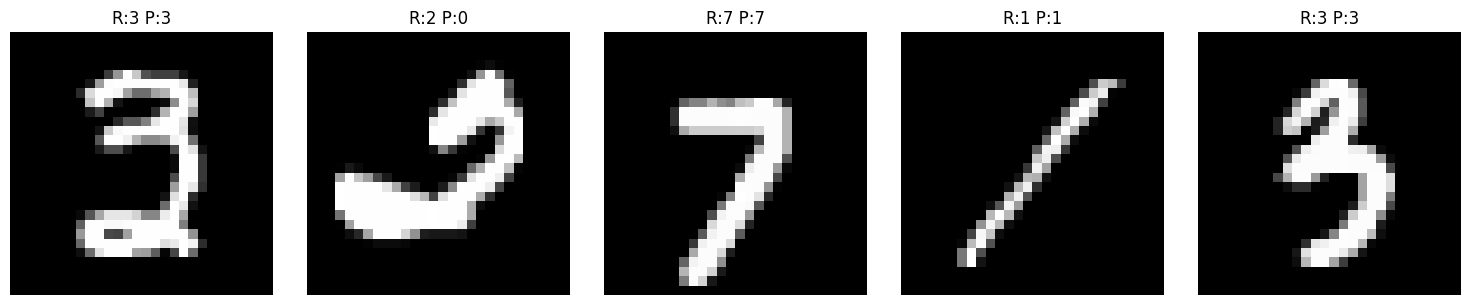

In [47]:
print(f"{V}Validando predicciones con imágenes del conjunto de validación{E}")

import matplotlib.pyplot as plt
import random

def mostrar_predicciones(modelo, loader, num_imagenes=5):
    modelo.eval()

    fig, axes = plt.subplots(1, num_imagenes, figsize=(15,3))
    contador = 0

    with torch.no_grad():
        for x, y in loader:
            out = modelo(x)
            _, pred = torch.max(out, 1)

            # Índices aleatorios del batch
            indices = random.sample(range(x.size(0)), num_imagenes)

            for idx in indices:
                img = x[idx].squeeze()

                axes[contador].imshow(img, cmap='gray')
                axes[contador].set_title(f"R:{y[idx].item()} P:{pred[idx].item()}")
                axes[contador].axis('off')

                if y[idx].item() == pred[idx].item():
                    print(f"{V}Imagen {contador+1}: Correcto{E}")
                else:
                    print(f"{R}Imagen {contador+1}: Incorrecto{E}")

                contador += 1

                if contador >= num_imagenes:
                    plt.tight_layout()
                    plt.show()
                    return

# Ejecutar función
mostrar_predicciones(mejor_modelo, val_loader, num_imagenes=5)

## Matriz de confusión

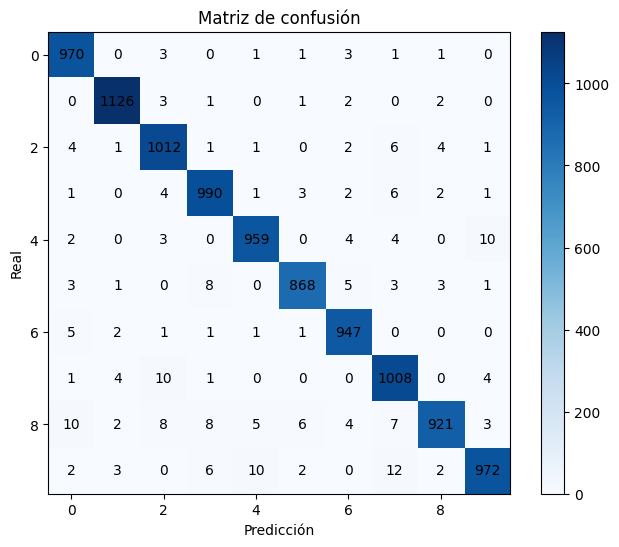

In [11]:
import numpy as np
import matplotlib.pyplot as plt

def matriz_confusion(modelo, loader):
    modelo.eval()

    matriz = np.zeros((10,10))

    with torch.no_grad():
        for x, y in loader:
            out = modelo(x)
            _, pred = torch.max(out, 1)

            for t, p in zip(y.numpy(), pred.numpy()):
                matriz[t][p] += 1

    # 🔹 Visualización
    plt.figure(figsize=(8,6))
    plt.imshow(matriz, cmap='Blues')
    plt.title("Matriz de confusión")
    plt.xlabel("Predicción")
    plt.ylabel("Real")

    # 🔹 Mostrar valores dentro de la matriz
    for i in range(10):
        for j in range(10):
            plt.text(j, i, int(matriz[i][j]), ha='center', va='center', color='black')

    plt.colorbar()
    plt.show()

matriz_confusion(mejor_modelo, test_loader)

## Reflexión

La actividad permitió entender cómo funciona el entrenamiento de una red neuronal desde cero. Se observó cómo los hiperparámetros afectan el desempeño del modelo. Además, el uso de validación y early stopping ayudó a evitar el sobreajuste.

También se comprobó que pequeños cambios en la arquitectura pueden generar mejoras en el rendimiento.

⚠️ **DISCLAIMER**

Algunas partes del código fueron apoyadas con inteligencia artificial.  
Entre ellas se incluyen la implementación de la matriz de confusión, la visualización de predicciones y la función de entrenamiento.  

También se utilizó apoyo en la división del dataset y en ciertos ajustes del flujo general.  

Todo el contenido fue revisado, comprendido y adaptado para cumplir con los objetivos del proyecto.